In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

# QuantKit Imports
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.engines.lsmc import LSMCEngine, LSMCConfig, BasisType, RegressionType
from quantkit.pricing.engines.binomial_tree import BinomialTreeEngine
from quantkit.pricing.utils.visualization import plot_exercise_boundaries, plot_exercise_boundary_binomial_bsm

# Set styling for presentation plots
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# QuantKit Imports
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.engines.lsmc import LSMCEngine, LSMCConfig
from quantkit.pricing.engines.bsm import BSMEngine

# Set styling for presentation plots
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Setup Market Data
market = MarketData(
    spot=100.0, 
    rate=0.05, 
    volatility=0.20, 
    dividend_yield=0.0  # Crucial: Must be 0 for American Call to equal European Call
)

# 2. Setup Instruments
eu_call = Option(strike=100.0, maturity=1.0, option_type=OptionType.CALL, style=OptionStyle.EUROPEAN)
eu_put = Option(strike=100.0, maturity=1.0, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN)
am_call = Option(strike=100.0, maturity=1.0, option_type=OptionType.CALL, style=OptionStyle.AMERICAN)

# 3. Get True BSM Baselines
bsm_eu_call_price = BSMEngine.price(eu_call, market).price
bsm_eu_put_price = BSMEngine.price(eu_put, market).price
bsm_am_call_price = bsm_eu_call_price # American Call (no div) equals European Call

print(f"BSM European Call Baseline: {bsm_eu_call_price:.4f}")
print(f"BSM European Put Baseline:  {bsm_eu_put_price:.4f}")
print(f"BSM American Call Baseline: {bsm_am_call_price:.4f}")

BSM European Call Baseline: 10.4506
BSM European Put Baseline:  5.5735
BSM American Call Baseline: 10.4506


### European Options Comparision

In [3]:
# # Define path counts (N)
# path_counts = [100, 500, 1000, 5000, 10000, 25000, 50000, 100000, 2000000]

# # Storage dictionaries
# results = {
#     "eu_call": {"prices": [], "errors": []},
#     "eu_put": {"prices": [], "errors": []},
#     "am_call": {"prices": [], "errors": []}
# }

# for n in path_counts:
#     # Use a fixed seed for smooth, reproducible convergence curves
#     cfg = LSMCConfig(n_paths=n, n_steps=50, seed=42, degree=5)
#     engine = LSMCEngine(cfg)
    
#     # Price European Call
#     price_ec = engine.price(eu_call, market).price
#     results["eu_call"]["prices"].append(price_ec)
#     results["eu_call"]["errors"].append(abs(price_ec - bsm_eu_call_price))
    
#     # Price European Put
#     price_ep = engine.price(eu_put, market).price
#     results["eu_put"]["prices"].append(price_ep)
#     results["eu_put"]["errors"].append(abs(price_ep - bsm_eu_put_price))
    
#     # Price American Call
#     price_ac = engine.price(am_call, market).price
#     results["am_call"]["prices"].append(price_ac)
#     results["am_call"]["errors"].append(abs(price_ac - bsm_am_call_price))

# print("Simulations complete!")

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # --- Plot 1: European Call Convergence ---
# axes[0].plot(path_counts, results["eu_call"]["prices"], marker='o', color='blue', label="MC Price")
# axes[0].axhline(bsm_eu_call_price, color='black', linestyle='--', label=f"BSM Exact ({bsm_eu_call_price:.3f})")
# axes[0].fill_between(path_counts, 
#                      bsm_eu_call_price - 0.1, bsm_eu_call_price + 0.1, 
#                      color='black', alpha=0.1, label="±$0.10 Error Band")
# axes[0].set_title("European Call Convergence")
# axes[0].set_xlabel("Number of Simulated Paths (N)")
# axes[0].set_ylabel("Option Price")
# axes[0].set_xscale("log")
# axes[0].legend()

# # --- Plot 2: European Put Convergence ---
# axes[1].plot(path_counts, results["eu_put"]["prices"], marker='s', color='red', label="MC Price")
# axes[1].axhline(bsm_eu_put_price, color='black', linestyle='--', label=f"BSM Exact ({bsm_eu_put_price:.3f})")
# axes[1].fill_between(path_counts, 
#                      bsm_eu_put_price - 0.1, bsm_eu_put_price + 0.1, 
#                      color='black', alpha=0.1, label="±$0.10 Error Band")
# axes[1].set_title("European Put Convergence")
# axes[1].set_xlabel("Number of Simulated Paths (N)")
# axes[1].set_ylabel("Option Price")
# axes[1].set_xscale("log")
# axes[1].legend()

# # --- Plot 3: Absolute Error Decay (All Instruments) ---
# axes[2].plot(path_counts, results["eu_call"]["errors"], marker='o', color='blue', label="European Call Error")
# axes[2].plot(path_counts, results["eu_put"]["errors"], marker='s', color='red', label="European Put Error")
# axes[2].plot(path_counts, results["am_call"]["errors"], marker='^', color='purple', label="American Call Error")
# axes[2].set_title("Absolute Pricing Error vs BSM")
# axes[2].set_xlabel("Number of Simulated Paths (N)")
# axes[2].set_ylabel("Absolute Error ($)")
# axes[2].set_xscale("log")
# axes[2].legend()

# plt.tight_layout()
# plt.show()

### 1. LSMC vs Binomial

Benchmark (Tree N=5000) Price: 6.0903
LSMC Price: 6.0565
Absolute Error: 0.0338


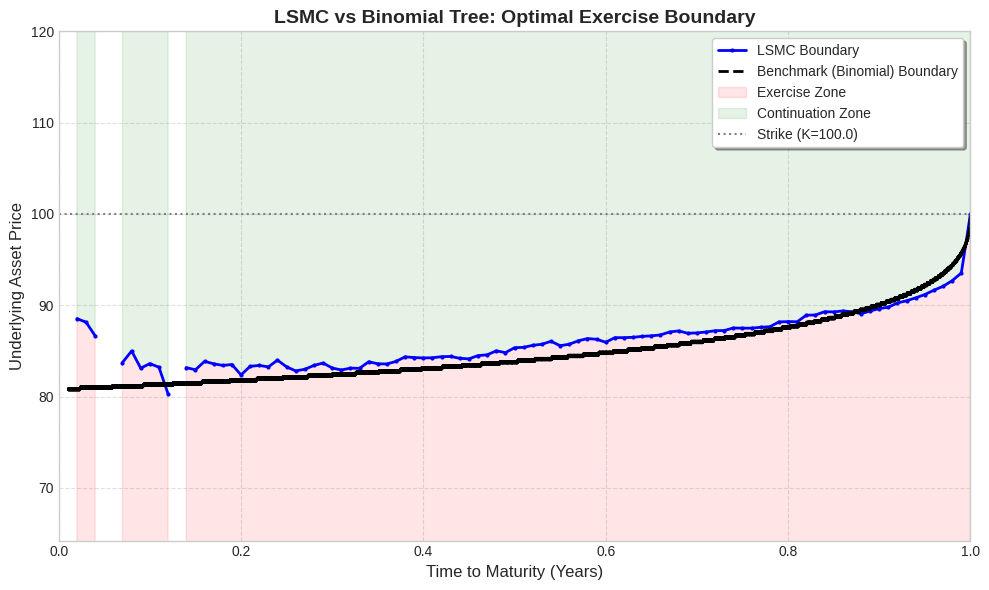

In [4]:
# Define Market Conditions
market = MarketData(
    spot=100.0, 
    rate=0.05, 
    volatility=0.20, 
    dividend_yield=0.0  # No dividend for this baseline
)

# Define the Instrument
american_put = Option(
    strike=100.0, 
    maturity=1.0, 
    option_type=OptionType.PUT, 
    style=OptionStyle.AMERICAN
)

# 1. Benchmark: High-Resolution Binomial Tree (True Price)
tree_engine = BinomialTreeEngine(steps=10000, model="crr")
benchmark_res = tree_engine.price(american_put, market)
print(f"Benchmark (Tree N=5000) Price: {benchmark_res.price:.4f}")

# 2. LSMC Engine Pricing
config = LSMCConfig(
    n_paths=100000, 
    n_steps=100, 
    basis_type=BasisType.LAGUERRE, 
    degree=3
)
lsmc_engine = LSMCEngine(config)
lsmc_res = lsmc_engine.price(american_put, market)
print(f"LSMC Price: {lsmc_res.price:.4f}")
print(f"Absolute Error: {abs(benchmark_res.price - lsmc_res.price):.4f}")

# Visualize the learned boundary vs the exact boundary
plot_exercise_boundaries(
    instrument=american_put, 
    lsmc_res=lsmc_res, 
    benchmark_res=benchmark_res,
    title="LSMC vs Binomial Tree: Optimal Exercise Boundary"
)

## 2. Convergence Analysis: Paths vs. Pricing Accuracy

A fundamental property of Monte Carlo methods is that the standard error of the estimate decreases at a rate of $1/\sqrt{N}$. However, in LSMC, $N$ (number of simulated paths) also controls the quality of the regression fit for the continuation value. Here, we track how the absolute error against the tree benchmark shrinks as we increase the number of simulated paths.

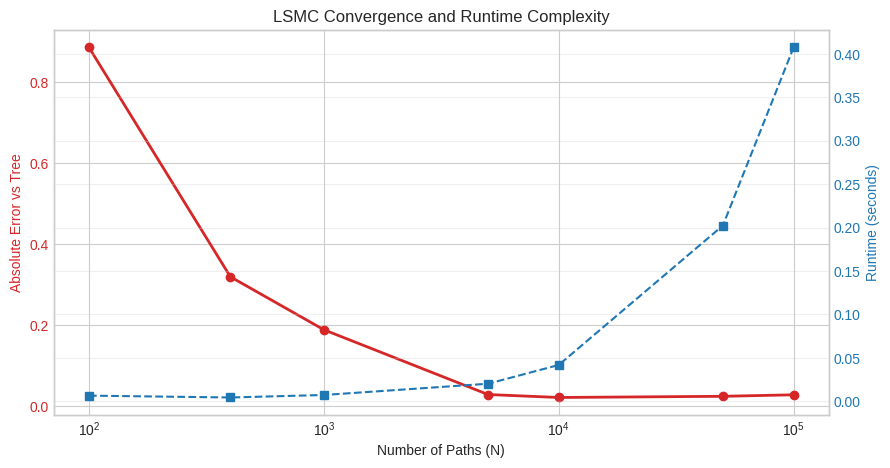

In [5]:
path_counts = [100,400, 1000, 5000, 10000, 50000, 100000]           
errors = []
runtimes = []

for n in path_counts:
    start_time = time.time()
    
    cfg = LSMCConfig(n_paths=n, n_steps=50, basis_type=BasisType.LAGUERRE, degree=3, seed=42)
    engine = LSMCEngine(cfg)
    price = engine.price(american_put, market).price
    
    runtimes.append(time.time() - start_time)
    errors.append(abs(price - benchmark_res.price))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Paths (N)')
ax1.set_ylabel('Absolute Error vs Tree', color=color)
ax1.plot(path_counts, errors, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Runtime (seconds)', color=color)  
ax2.plot(path_counts, runtimes, marker='s', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('LSMC Convergence and Runtime Complexity')
plt.xscale('log') # Log scale helps visualize the N distribution better
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
degrees = [2, 3, 4, 5]
basis_types = [BasisType.LAGUERRE, BasisType.HERMITE, BasisType.POLYNOMIAL]

results = []

for basis in basis_types:
    for deg in degrees:
        cfg = LSMCConfig(n_paths=50000, n_steps=50, basis_type=basis, degree=deg, seed=123)
        engine = LSMCEngine(cfg)
        
        start_time = time.time()
        price = engine.price(american_put, market).price
        exec_time = time.time() - start_time
        
        error = abs(price - benchmark_res.price)
        
        results.append({
            "Basis": basis.value.capitalize(),
            "Degree": deg,
            "Price": round(price, 4),
            "Error": round(error, 5),
            "Time (s)": round(exec_time, 3)
        })

df_ml_study = pd.DataFrame(results)
display(df_ml_study.sort_values(by="Error").reset_index(drop=True))

,Basis,Degree,Price,Error,Time (s)
0,Laguerre,4,6.0888,0.00151,0.196
1,Hermite,4,6.0888,0.00151,0.202
2,Polynomial,4,6.0888,0.00151,0.200
3,Hermite,3,6.0859,0.00443,0.194
4,Polynomial,3,6.0859,0.00443,0.207
5,Laguerre,3,6.0859,0.00443,0.224
6,Hermite,5,6.0847,0.00563,0.220
7,Polynomial,5,6.0847,0.00563,0.204
8,Laguerre,5,6.0845,0.00582,0.221
9,Laguerre,2,6.0582,0.03209,0.190


## Real World Data Demonstration

In this section, we'll demonstrate the extended LSMC engine using real market data fetched via `yfinance`.

We will cover:
1. **Current Snapshot Comparison**: Comparing the LSMC American price with the actual market price for a snapshot of popular stocks.
2. **Historical Option Tracking**: Simulating the price of a single stock option over its lifetime and comparing the American LSMC price with the European Black-Scholes proxy.
3. **Historical Basket Option Tracking**: Pricing a multi-asset custom basket option over time.


### 1. Snapshot Market Comparison

Fetching data and pricing options...


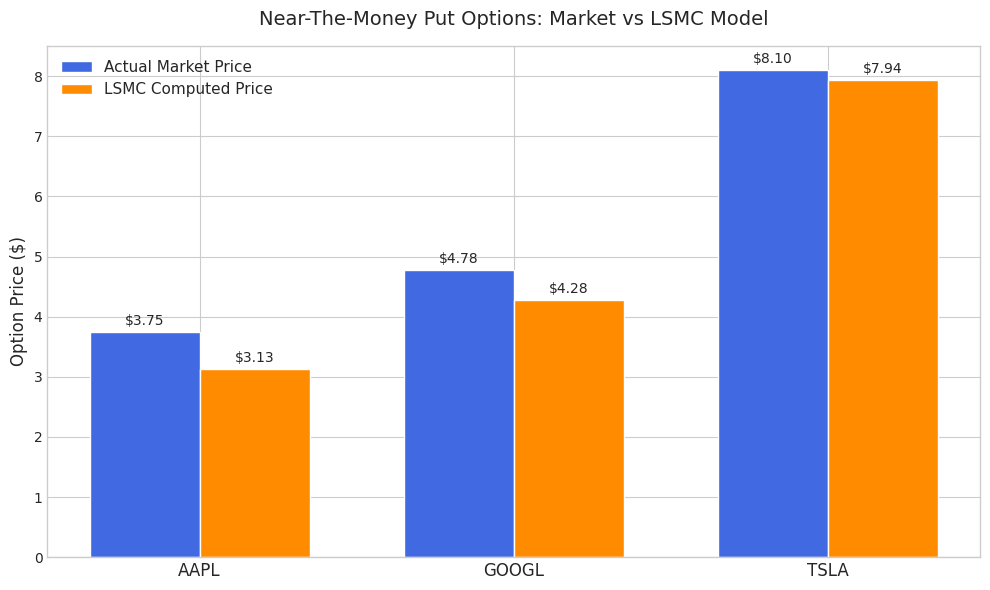

In [7]:
import yfinance as yf
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from quantkit.pricing.core.instruments import Option, OptionType, OptionStyle
from quantkit.pricing.core.market import MarketData
from quantkit.pricing.engines.lsmc import LSMCEngine, LSMCConfig
import warnings
warnings.filterwarnings("ignore")

tickers = ['AAPL', 'GOOGL', 'TSLA']
results = []

# Risk-free rate proxy
irx = yf.Ticker('^IRX')
r_hist = irx.history(period="1mo")
r = (r_hist['Close'].iloc[-1]) / 100.0

print("Fetching data and pricing options...")

for ticker in tickers:
    tk = yf.Ticker(ticker)
    hist = tk.history(period="1y")
    S0 = hist['Close'].iloc[-1]
    
    log_rets = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
    vol = log_rets.std() * np.sqrt(252)
    
    expirations = tk.options
    if not expirations:
        continue
    exp_date = expirations[2]  # Near-term expiration
    chain = tk.option_chain(exp_date)
    
    puts = chain.puts
    puts['abs_dist'] = abs(puts['strike'] - S0)
    atm_put = puts.sort_values('abs_dist').iloc[0]
    
    K = atm_put['strike']
    market_price = atm_put['lastPrice']
    
    T = (datetime.strptime(exp_date, "%Y-%m-%d") - datetime.now()).days / 365.25
    if T <= 0: T = 0.01
    
    instrument = Option(strike=K, maturity=T, option_type=OptionType.PUT, style=OptionStyle.AMERICAN)
    market = MarketData(spot=S0, rate=r, volatility=vol)
    
    cfg = LSMCConfig(n_paths=500000, n_steps=100, seed=67)
    engine = LSMCEngine(cfg)
    lsmc_res = engine.price(instrument, market)
    
    results.append({
        'Ticker': ticker,
        'Market Price': market_price,
        'LSMC Price': lsmc_res.price
    })

# Plotting the results
labels = [res['Ticker'] for res in results]
market_prices = [res['Market Price'] for res in results]
lsmc_prices = [res['LSMC Price'] for res in results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
rects1 = ax.bar(x - width/2, market_prices, width, label='Actual Market Price', color='royalblue')
rects2 = ax.bar(x + width/2, lsmc_prices, width, label='LSMC Computed Price', color='darkorange')

ax.set_ylabel('Option Price ($)', fontsize=12)
ax.set_title('Near-The-Money Put Options: Market vs LSMC Model', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=11)

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()


### 2. Historical Option Tracking (Single Stock)

Because historical option prices are not freely available, we will compute the American LSMC price of a hypothetical AAPL put option historically over the past 3 months. 
We compare this against the theoretical European Black-Scholes price (which acts as our proxy baseline) and plot the underlying stock price.


Calculating historical option prices...


100%|██████████| 62/62 [00:01<00:00, 45.66it/s]


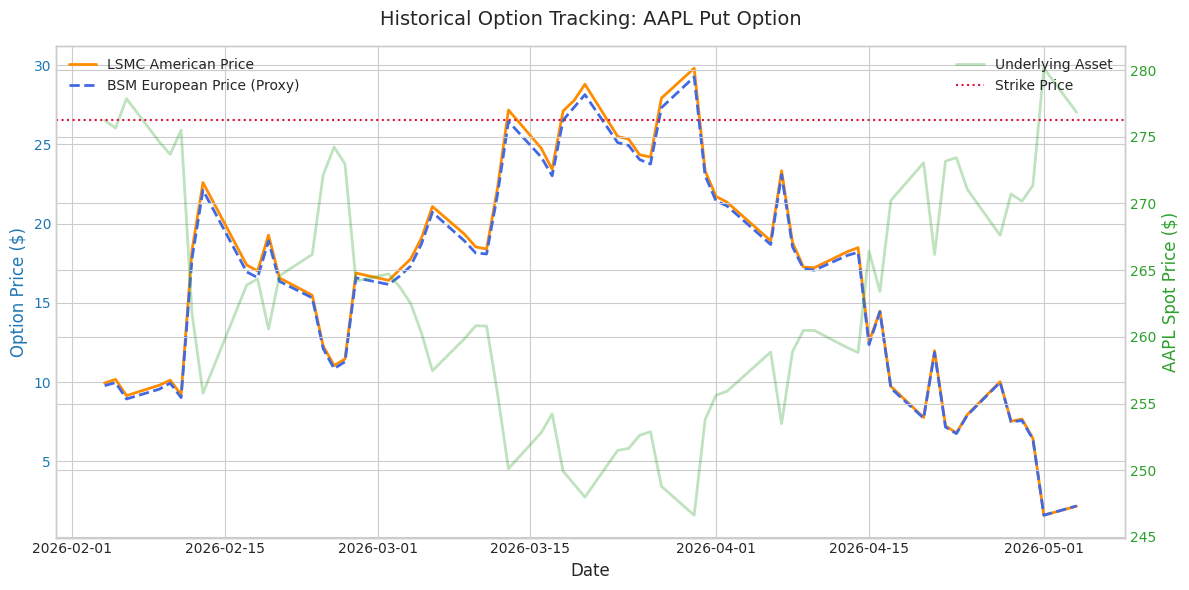

In [8]:
from quantkit.pricing.engines.bsm import BSMEngine
from tqdm import tqdm

aapl = yf.Ticker('AAPL')
hist_data = aapl.history(period="6mo")
hist_prices = hist_data['Close']

# Compute 3-month rolling volatility
rolling_vol = np.log(hist_prices / hist_prices.shift(1)).rolling(window=63).std() * np.sqrt(252)

# Slice the last 3 months for our tracking
track_prices = hist_prices[-63:]
track_vols = rolling_vol[-63:]

# Assume an option expiring at the last day of our tracking period
K = track_prices.iloc[0]  # ATM at the start of the period
T_max = 63 / 252.0

lsmc_history = []
bsm_history = []
dates = []

bsm_engine = BSMEngine()
cfg = LSMCConfig(n_paths=10000, n_steps=30, seed=123)
lsmc_engine = LSMCEngine(cfg)

print("Calculating historical option prices...")
for i in tqdm(range(len(track_prices) - 1)):  # Skip the very last day (T=0)
    current_S = track_prices.iloc[i]
    current_vol = track_vols.iloc[i]
    if np.isnan(current_vol): current_vol = 0.20
    
    current_T = T_max - (i / 252.0)
    
    instrument = Option(strike=K, maturity=current_T, option_type=OptionType.PUT, style=OptionStyle.AMERICAN)
    eur_instrument = Option(strike=K, maturity=current_T, option_type=OptionType.PUT, style=OptionStyle.EUROPEAN)
    market = MarketData(spot=current_S, rate=r, volatility=current_vol)
    
    # LSMC American
    lsmc_price = lsmc_engine.price(instrument, market).price
    lsmc_history.append(lsmc_price)
    
    # BSM European
    bsm_price = bsm_engine.price(eur_instrument, market).price
    bsm_history.append(bsm_price)
    
    dates.append(track_prices.index[i])

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Option Price ($)', color=color, fontsize=12)
ax1.plot(dates, lsmc_history, label='LSMC American Price', color='darkorange', linewidth=2)
ax1.plot(dates, bsm_history, label='BSM European Price (Proxy)', color='royalblue', linestyle='--', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('AAPL Spot Price ($)', color=color, fontsize=12)
ax2.plot(dates, track_prices.iloc[:-1], color=color, alpha=0.3, linewidth=2, label='Underlying Asset')
ax2.axhline(y=K, color='crimson', linestyle=':', label='Strike Price')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Historical Option Tracking: AAPL Put Option', fontsize=14, pad=15)
fig.tight_layout()
plt.show()


### 3. Historical Basket Option Tracking

We apply the same historical tracking logic to an OTC multi-asset product: an **Average Basket Option** of Tech stocks (AAPL, MSFT, GOOGL). Since there are absolutely no market prices for this custom OTC product, we track the LSMC price relative to the intrinsic basket value.


Calculating historical basket option prices...


100%|██████████| 62/62 [00:02<00:00, 22.77it/s]


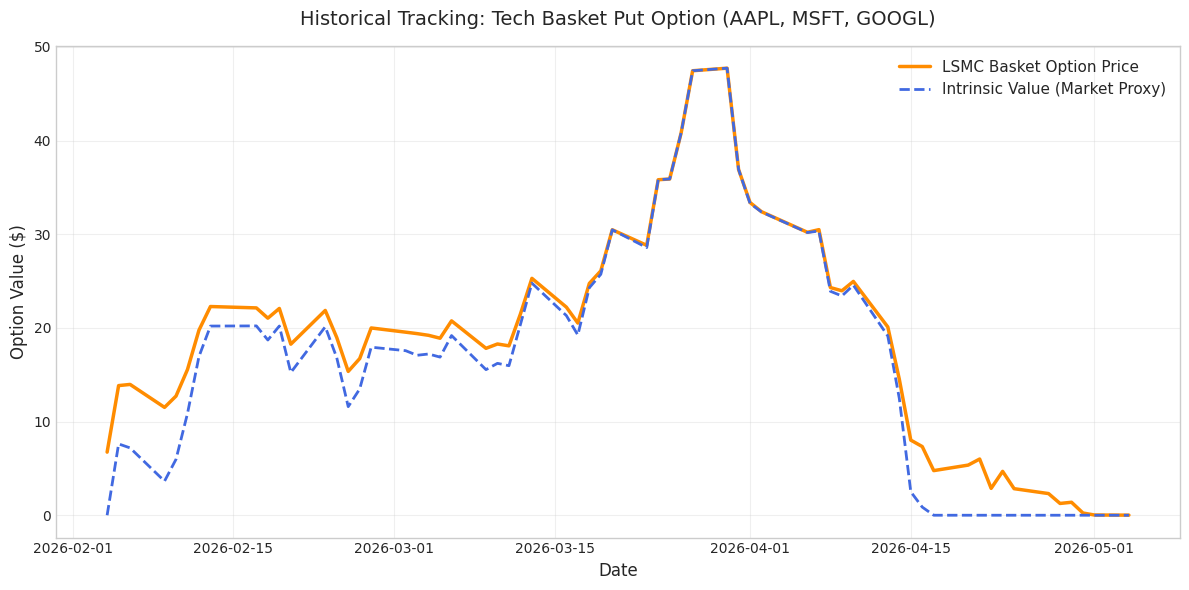

In [9]:
from quantkit.pricing.core.instruments import BasketOption, BasketType
from quantkit.pricing.core.market import MultiAssetMarketData

basket_tickers = ['AAPL', 'MSFT', 'GOOGL']
basket_data = yf.download(basket_tickers, period='6mo', progress=False, auto_adjust=True)['Close'][basket_tickers]

# Calculate rolling covariance elements manually (as Pandas rolling cov for multi-index is tricky)
rets = np.log(basket_data / basket_data.shift(1)).dropna()

track_len = 63
hist_spots = basket_data[-track_len:]
hist_rets = rets[-track_len:]

# Initial strike based on the average spot price 3 months ago
K_basket = np.mean(hist_spots.iloc[0].values)
T_max = track_len / 252.0

lsmc_basket_history = []
intrinsic_history = []
basket_dates = []

cfg_multi = LSMCConfig(n_paths=10000, n_steps=30, seed=123)
engine_multi = LSMCEngine(cfg_multi)

print("Calculating historical basket option prices...")
# We use a static 3-month trailing covariance matrix for simplicity at each step
for i in tqdm(range(len(hist_spots) - 1)):
    current_spots = hist_spots.iloc[i].values
    
    # Use trailing 60 days of returns up to current day `i`
    # We find the absolute index in `rets` corresponding to `hist_spots.iloc[i]`
    current_date = hist_spots.index[i]
    ret_idx = rets.index.get_loc(current_date)
    trailing_rets = rets.iloc[ret_idx-60:ret_idx]
    
    current_vols = trailing_rets.std().values * np.sqrt(252)
    current_corr = trailing_rets.corr().values
    
    # Fallback if corr matrix is invalid (e.g. at the very start if not enough data)
    if np.any(np.isnan(current_corr)):
        current_vols = np.array([0.2, 0.2, 0.2])
        current_corr = np.eye(3)
        
    current_T = T_max - (i / 252.0)
    
    multi_market = MultiAssetMarketData(
        spot=current_spots,
        rate=r,
        volatility=current_vols,
        correlation_matrix=current_corr
    )
    
    basket_instrument = BasketOption(
        strike=K_basket,
        maturity=current_T,
        option_type=OptionType.PUT,
        style=OptionStyle.AMERICAN,
        basket_type=BasketType.AVERAGE,
        weights=np.array([1/3, 1/3, 1/3])
    )
    
    basket_price = engine_multi.price(basket_instrument, multi_market).price
    
    # Calculate current intrinsic value
    current_basket_val = np.mean(current_spots)
    intrinsic_val = max(K_basket - current_basket_val, 0.0)
    
    lsmc_basket_history.append(basket_price)
    intrinsic_history.append(intrinsic_val)
    basket_dates.append(current_date)

plt.figure(figsize=(12, 6))
plt.plot(basket_dates, lsmc_basket_history, label='LSMC Basket Option Price', color='darkorange', linewidth=2.5)
plt.plot(basket_dates, intrinsic_history, label='Intrinsic Value (Market Proxy)', color='royalblue', linestyle='--', linewidth=2)

plt.title('Historical Tracking: Tech Basket Put Option (AAPL, MSFT, GOOGL)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Option Value ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
